# Pillar Text vs Grade: Position & Era Signal

This notebook brings together the pillar_scores_v3_2_bin dataset to visualize how "god-given" (ceiling) versus "learned" (technique/mental) language varies by grade bucket, position, and era. It also highlights players whose text-derived signal deviates meaningfully from their grade (residuals) so we can pinpoint when the prose adds signal beyond the numeric grade. All figures are saved into nalysis_outputs.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LinearRegression

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_PATH = Path('..') / 'data' / 'processed' / 'pillar_scores_v3_2_bin.csv'
OUTPUT_DIR = Path('..') / 'analysis_outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

GRADE_CUTOFF = 2014  # grades prior to 2014 use the old 0-100 scale

df = pd.read_csv(DATA_PATH)
df = df[df['grade'].notna()].copy()
df = df[df['year'] >= GRADE_CUTOFF]
df['Pos_Group'] = df['Pos_Group'].fillna('Unknown')

df['grade_scale'] = np.where(df['year'] >= GRADE_CUTOFF, 'post-2014 (5-7 scale)', 'pre-2014 (0-100 scale)')

score_cols = ['score_god_given', 'score_learned']
pct_cols = ['score_god_given_pct', 'score_learned_pct']

q1 = df['grade'].quantile(0.25)
q3 = df['grade'].quantile(0.75)
labels = ['Low', 'Mid', 'High']
bins = [-np.inf, q1, q3, np.inf]
df['grade_group'] = pd.cut(df['grade'], bins=bins, labels=labels, ordered=True)

print(f'Loaded {len(df):,} graded entries (>= {GRADE_CUTOFF}).')
print('Note: grades earlier than 2014 used a 0-100 scale, while 2014+ entries live around 5-7.5.')
print('Position counts (>=100):')
print(df['Pos_Group'].value_counts()[lambda s: s >= 100].to_string())
print('\nGod/learned pct quartile thresholds (post-2014 scale only):')
print(f'  Q1={q1:.2f}  Q3={q3:.2f}')

Loaded 5,383 graded entries (>= 2014).
Note: grades earlier than 2014 used a 0-100 scale, while 2014+ entries live around 5-7.5.
Position counts (>=100):
Pos_Group
DB         1029
OL          911
WR          751
EDGE        651
RB          489
DT          445
LB          423
TE          313
QB          233
SPECIAL     138

God/learned pct quartile thresholds (post-2014 scale only):
  Q1=5.60  Q3=6.11


## Grade Buckets & Position Mix

Compare the mean god-given/learned percent mix for each position and grade bucket. This highlights how scouts use explosive language for elite (High) grades while the learned/technique narrative dominates the lower tiers. The bar chart is limited to positions with ample samples (QB, LB, DB, RB, EDGE, WR).

Mean pct by position and grade bucket (excerpt)
            score_god_given_pct             score_learned_pct            
grade_group                 Low   Mid  High               Low   Mid  High
Pos_Group                                                                
DB                         51.0  52.3  53.5              49.0  47.7  46.5
EDGE                       55.2  56.8  65.2              44.8  43.2  34.8
LB                         33.8  43.5  63.6              66.2  56.5  36.4
QB                         44.7  48.6  58.0              55.3  51.4  42.0
RB                         56.3  52.5  58.6              43.7  47.5  41.4
WR                         62.2  58.7  64.0              37.8  41.3  36.0


C:\Users\sffra\AppData\Local\Temp\ipykernel_42828\572025956.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Pos_Group', 'grade_group'])[pct_cols]
C:\Users\sffra\AppData\Local\Temp\ipykernel_42828\572025956.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  print(summary.pivot_table(index='Pos_Group', columns='grade_group', values=['score_god_given_pct', 'score_learned_pct']).round(1))


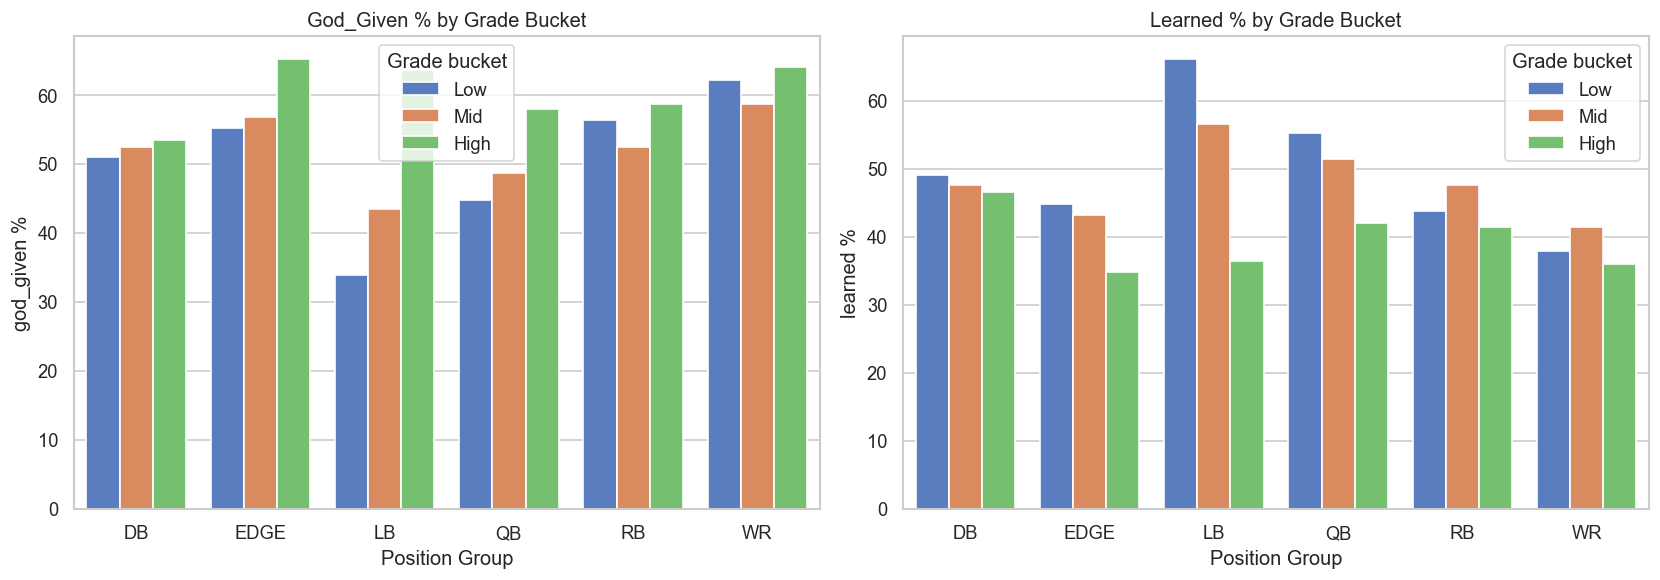

In [2]:
pos_focus = ['QB', 'LB', 'DB', 'RB', 'EDGE', 'WR']
summary = (
    df[df['Pos_Group'].isin(pos_focus)]
      .groupby(['Pos_Group', 'grade_group'])[pct_cols]
      .mean()
      .reset_index()
)
print('Mean pct by position and grade bucket (excerpt)')
print(summary.pivot_table(index='Pos_Group', columns='grade_group', values=['score_god_given_pct', 'score_learned_pct']).round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pillar in zip(axes, pct_cols):
    sns.barplot(
        data=summary,
        x='Pos_Group',
        y=pillar,
        hue='grade_group',
        ax=ax
    )
    ax.set_xlabel('Position Group')
    ax.set_ylabel(pillar.replace('score_', '').replace('_pct', ' %'))
    ax.set_title(f"{pillar.replace('score_', '').replace('_pct', '').title()} % by Grade Bucket")
    ax.legend(title='Grade bucket')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'grade_bucket_god_learned_pct.png')
plt.show()


## Era-level Drift for High Grades

Track the average god-given share of the top quartile of graded players per year by position. This lets us see whether high-grade prospects (especially QB/EDGE/LB) were described primarily in terms of ceiling traits or technique over time.

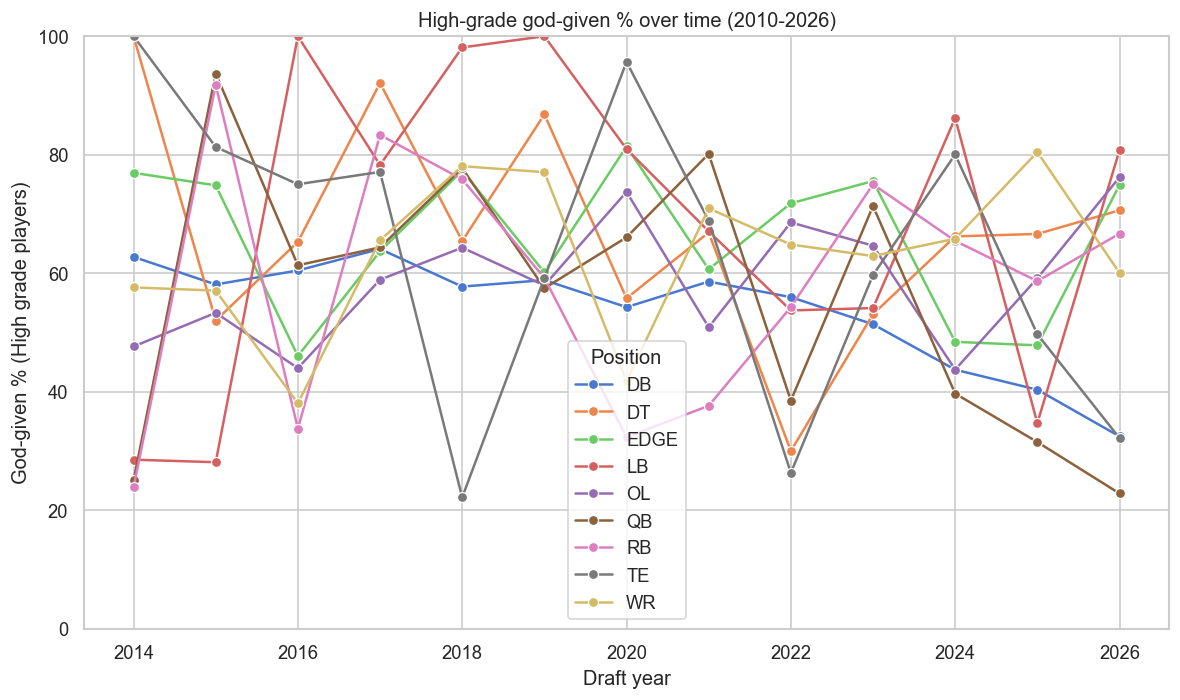

In [3]:
high_df = df[df['grade'] >= q3]
yearly = (
    high_df.groupby(['year', 'Pos_Group'])[pct_cols]
           .mean()
           .reset_index()
)
valid = yearly['Pos_Group'].value_counts()[lambda s: s >= 5].index
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=yearly[yearly['Pos_Group'].isin(valid)],
    x='year',
    y='score_god_given_pct',
    hue='Pos_Group',
    marker='o',
    ax=ax
)
ax.set_title('High-grade god-given % over time (2010-2026)')
ax.set_ylabel('God-given % (High grade players)')
ax.set_xlabel('Draft year')
ax.set_ylim(0, 100)
ax.legend(title='Position')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'era_god_pct_high_grades.png')
plt.show()


## Residuals: when text and grade disagree

Fit a simple linear model grade ~ score_god_given + score_learned and inspect residuals. Points far above/below 0 indicate players whose language signal deviates from the grade, which surfaces cases where the scout report added nuance beyond the numeric grade. Only positions with =100 samples are shown in the scatter to avoid over-interpreting small subsets.

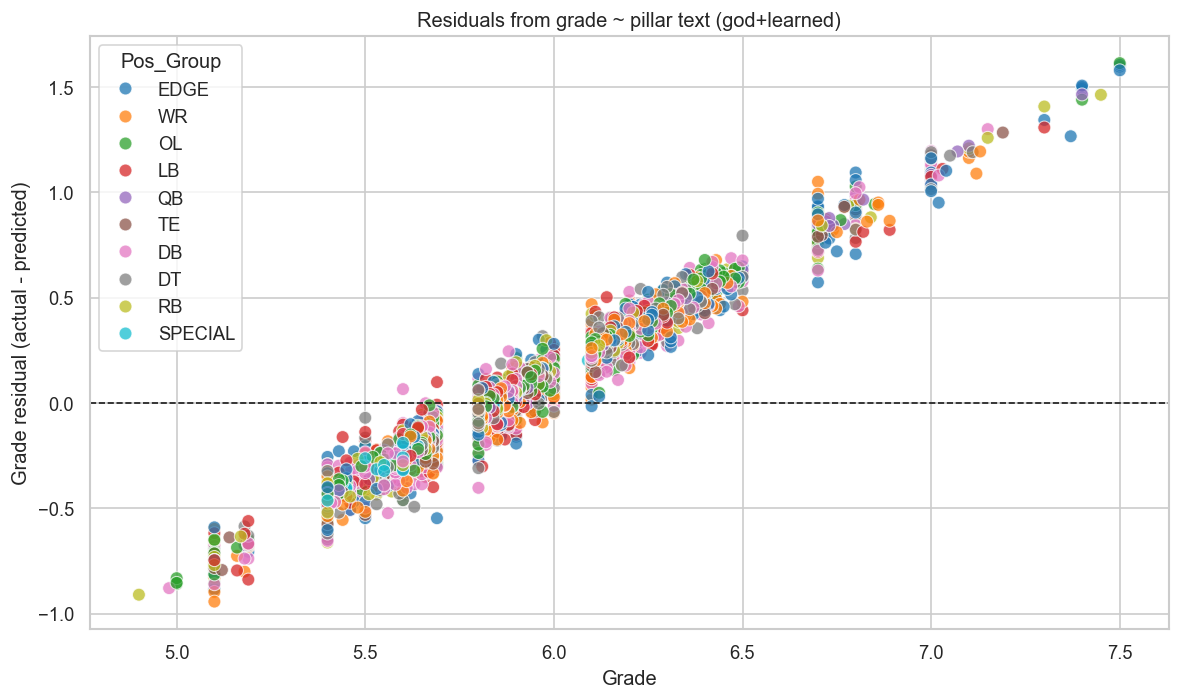

Top positive residuals (grade > text)
     player_name Pos_Group  grade  grade_resid  score_god_given  score_learned
   Laremy Tunsil        OL    7.5     1.612683             48.9           46.4
      Myles Jack      EDGE    7.5     1.604925             48.7           54.0
Jadeveon Clowney      EDGE    7.5     1.596209             53.9           29.2
   Myles Garrett      EDGE    7.5     1.578471             57.1           24.1
   Bradley Chubb      EDGE    7.4     1.506065             51.2           37.7

Top negative residuals (text > grade)
    player_name Pos_Group  grade  grade_resid  score_god_given  score_learned
D.J. Montgomery        WR    5.1    -0.942883             71.2           37.1
Jacques Patrick        RB    4.9    -0.910286             38.9           44.6
   Corey Holmes        WR    5.1    -0.897094             65.7           33.3
    Matt Lengel        TE    5.1    -0.888248             63.2           41.4
 Cory Littleton      EDGE    5.1    -0.884192             6

In [4]:
model = LinearRegression()
model.fit(df[score_cols], df['grade'])
df['grade_pred'] = model.predict(df[score_cols])
df['grade_resid'] = df['grade'] - df['grade_pred']
keep = df['Pos_Group'].value_counts()[lambda s: s >= 100].index
disp = df[df['Pos_Group'].isin(keep)]
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=disp,
    x='grade',
    y='grade_resid',
    hue='Pos_Group',
    palette='tab10',
    alpha=0.75,
    edgecolor='w',
    s=60,
    ax=ax
)
ax.axhline(0, color='k', linestyle='--', linewidth=1)
ax.set_title('Residuals from grade ~ pillar text (god+learned)')
ax.set_ylabel('Grade residual (actual - predicted)')
ax.set_xlabel('Grade')
ax.legend(title='Pos_Group')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'grade_text_residuals.png')
plt.show()

print('Top positive residuals (grade > text)')
print(df.nlargest(5, 'grade_resid')[['player_name', 'Pos_Group', 'grade', 'grade_resid', 'score_god_given', 'score_learned']].to_string(index=False))
print('\nTop negative residuals (text > grade)')
print(df.nsmallest(5, 'grade_resid')[['player_name', 'Pos_Group', 'grade', 'grade_resid', 'score_god_given', 'score_learned']].to_string(index=False))